In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
### Read and filter pressure and snow height data from aws

# Read AWS data
file_path_aws = "HEF30_lf.dat"
df_aws = pd.read_csv(
    file_path_aws,
    skiprows=[0, 2, 3],
    parse_dates=["TIMESTAMP"],
    na_values=["NaN", ""],
)

df_aws["TIMESTAMP"] = pd.to_datetime(df_aws["TIMESTAMP"])
df_aws["Press_Avg"] = pd.to_numeric(df_aws["Press_Avg"], errors="coerce")
df_aws.set_index("TIMESTAMP", inplace=True)
df_aws = df_aws.sort_index()



# Calculate 5th and 95th percentiles over 7-day rolling window (hourly data)
lower_bound_p = df_aws["Press_Avg"].rolling(window="7D", center=True).quantile(0.1)
upper_bound_p = df_aws["Press_Avg"].rolling(window="7D", center=True).quantile(0.9)

# Filter counts within 5-95 percentile range
df_aws_filtered = df_aws[(df_aws["Press_Avg"] >= lower_bound_p) & (df_aws["Press_Avg"] <= upper_bound_p)].copy()

# Resample AWS data to hourly average to align with neutron counts
df_aws_hourly = df_aws["Press_Avg"].resample("h").mean()

df_aws_filtered["p_daily_median"] = df_aws_filtered["Press_Avg"].rolling("1D").median()


# Calculate 5th and 95th percentiles over 7-day rolling window
lower_bound_aws = df_aws["Snow_Depth"].rolling(window="7D", center=True).quantile(0.1)
upper_bound_aws = df_aws["Snow_Depth"].rolling(window="7D", center=True).quantile(0.9)

# Mask values within the 5th–95th percentile range
mask = (df_aws["Snow_Depth"] >= lower_bound_aws) & (df_aws["Snow_Depth"] <= upper_bound_aws)

# Create a filtered series (outside values are NaN)
sd_filtered = df_aws["Snow_Depth"].where(mask)


In [3]:
### Read raw CRNS data, filter outliers and caculate SWE from neutron counts (including pressure correction)


file_path = "HEF30_snowfox_data_table.dat"

# Read the file with correct header and date parsing
df = pd.read_csv(
    file_path,
    skiprows=[0, 2, 3],             # skip metadata and units rows
    parse_dates=["TIMESTAMP"],      # parse datetime column
    na_values=["NaN", ""],          # handle blanks as NaN
)

# Ensure TIMESTAMP and counts are properly typed
df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"])
df["counts"] = pd.to_numeric(df["counts"], errors="coerce")

# Set timestamp as index and sort
df.set_index("TIMESTAMP", inplace=True)
df = df.sort_index()

# --- NEW STEP: Resample to hourly sums ---
df_hourly = df["counts"].resample("h").sum(min_count=1)  # sum counts over each hour

# Convert back to DataFrame
df_hourly = df_hourly.to_frame()

# --- Continue with hourly data ---
# Calculate 5th and 95th percentiles over 7-day rolling window (hourly data)
lower_bound = df_hourly["counts"].rolling(window="7D", center=True).quantile(0.1)
upper_bound = df_hourly["counts"].rolling(window="7D", center=True).quantile(0.9)

# Filter counts within 5-95 percentile range
df_filtered = df_hourly[(df_hourly["counts"] >= lower_bound) & (df_hourly["counts"] <= upper_bound)].copy()

# 1-day rolling median on filtered hourly counts
df_filtered["counts_daily_median"] = df_filtered["counts"].rolling("1D").median()
df_hourly["counts_daily_median"] = df_hourly["counts"].rolling("1D").median()

# Filter out zero or negative counts to avoid log issues
df_filtered = df_filtered[df_filtered["counts"] > 0].copy()



# Join pressure to filtered counts (align by index)
df_filtered = df_filtered.join(df_aws_hourly, how="inner")

# Function to compute SWE (updated for hourly counts)
def compute_swe(df, p_col, n_col, N0):
    Lmax = 114.4  # cm
    Lmin = 14.1   # cm
    a1 = 0.313
    a2 = 0.082
    a3 = 1.117
    beta = 0.0075  # hPa^-1

    P = p_col
    P_avg = P.mean()
    f_bar = np.exp(beta * (P - P_avg))


    f_sol = 1

    N_raw = n_col
    N_corr = N_raw * f_bar * f_sol

    L_i_inv = (1 / Lmax) + ((1 / Lmin - 1 / Lmax) * (1 + np.exp(-((N_corr / N0 - a1) / a2)))**(-a3))
    L_i = 1 / L_i_inv

    SWE_mm = -10 * L_i * np.log(N_corr / N0)

    df = df.copy()
    df["N_corr"] = N_corr
    df["L_eff_cm"] = L_i
    df["SWE_mm"] = SWE_mm

    return df

# Compute SWE on hourly data
df_filtered = compute_swe(df_filtered, p_col=df_filtered["Press_Avg"], n_col=df_filtered["counts"], N0=5200)#6032

In [4]:
### Calculate daily snow density from SWE and snow height

# Daily stats: median, 5th and 95th percentiles
daily_swe = df_filtered["SWE_mm"].resample("D").agg({
    "median": "median",
    "p05": lambda x: x.quantile(0.05),
    "p95": lambda x: x.quantile(0.95),
})
daily_swe.dropna(inplace=True)

# Hourly mean
hourly_swe = df_filtered["SWE_mm"].resample("h").mean()


daily_sd = sd_filtered.resample("D").median()
density = daily_swe["median"] / daily_sd.values

In [5]:
### Read SWE output from various models (removed first line (zeros) in the file!!!)

# Load the CSV properly: split on commas, and disable quoting so headers are parsed correctly
file_path = "swe_snow_data_export.csv"
df_models = pd.read_csv(file_path, delimiter=",", quoting=3)  # quoting=3 means QUOTE_NONE

# Strip quotes from column headers if any
df_models.columns = df_models.columns.str.replace('"', '').str.strip()

# Ensure 'date' column is treated as datetime
df_models["date"] = pd.to_datetime(df_models["date"])


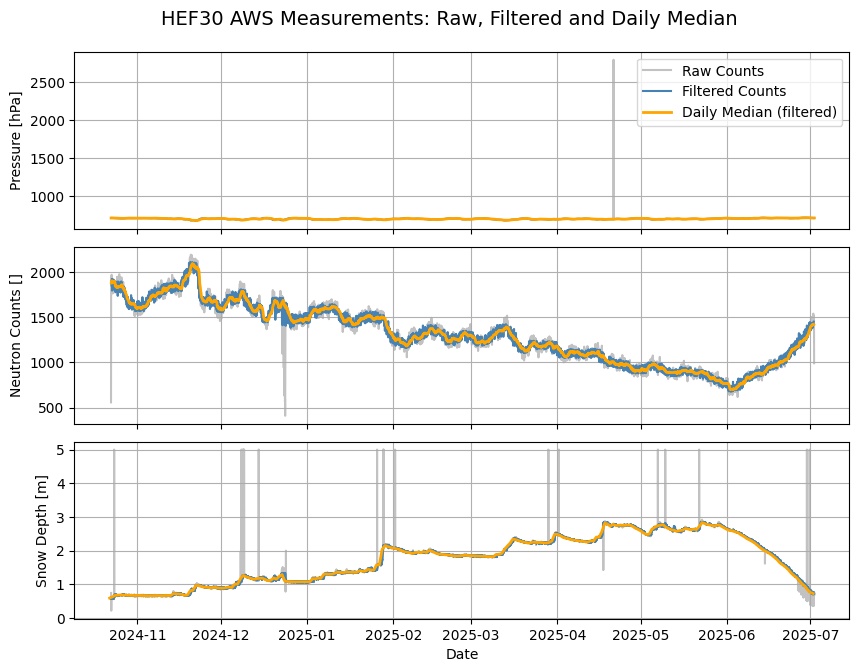

In [6]:
### Plot data filtering


# Create subplots: 3 rows, 1 column, shared x-axis
fig, axs = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

# --- 1. Pressure Plot ---
axs[0].plot(df_aws.index, df_aws["Press_Avg"], color="darkgrey", label="Raw Counts", alpha=0.7)
axs[0].plot(df_aws_filtered.index, df_aws_filtered["Press_Avg"], color="steelblue", label="Filtered Counts")
axs[0].plot(df_aws_filtered.index, df_aws_filtered["p_daily_median"], color="orange", linewidth=2, label="Daily Median (filtered)")
axs[0].set_ylabel("Pressure [hPa]")
axs[0].legend()
axs[0].grid(True)

# --- 2. Neutron Counts Plot ---
axs[1].plot(df_hourly.index, df_hourly["counts"], color="darkgrey", label="Raw Counts", alpha=0.7)
axs[1].plot(df_filtered.index, df_filtered["counts"], color="steelblue", label="Filtered Counts")
axs[1].plot(df_filtered.index, df_filtered["counts_daily_median"], color="orange", linewidth=2, label="Daily Median (filtered)")
axs[1].set_ylabel("Neutron Counts []")
#axs[1].legend()
axs[1].grid(True)

# --- 3. Snow Depth Plot ---
axs[2].plot(df_aws.index, df_aws["Snow_Depth"], color="darkgrey", label="Raw Snow Depth", alpha=0.7)
axs[2].plot(df_aws.index, sd_filtered, color="steelblue", label="Filtered Counts")
axs[2].plot(daily_swe.index, sd_filtered.resample("D").median(), color="orange", linewidth=2, label="Daily Median (filtered)")
axs[2].set_ylabel("Snow Depth [m]")
axs[2].set_xlabel("Date")
#axs[2].legend()
axs[2].grid(True)

# --- Overall title and layout ---
fig.suptitle("HEF30 AWS Measurements: Raw, Filtered and Daily Median", fontsize=14)
#plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave room for suptitle
fig.subplots_adjust(hspace=0.1, top=0.92)

plt.show()


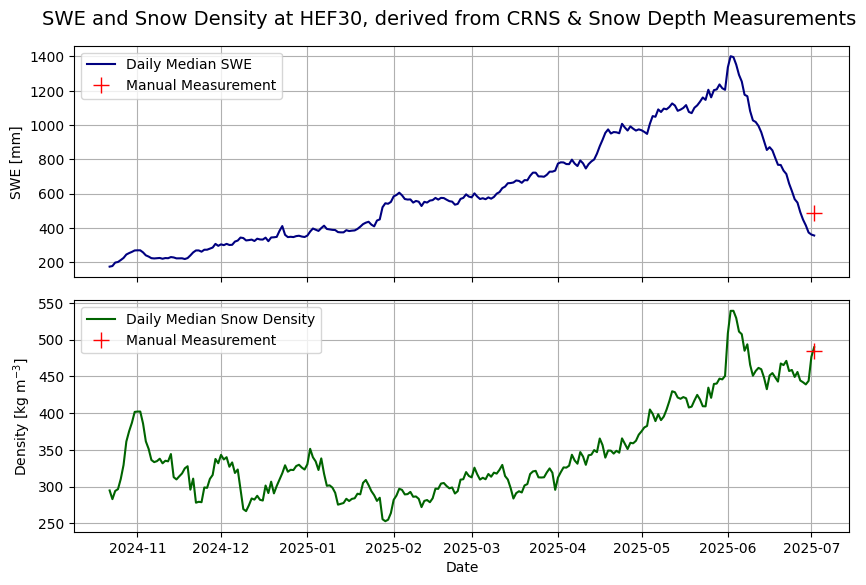

In [7]:
### Plot CRNS measurements (SWE and density)


# Create subplots: 2 rows, 1 column, shared x-axis
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# --- 1. SWE Median Plot ---
axs[0].plot(daily_swe.index, daily_swe["median"], color="navy", label="Daily Median SWE")
axs[0].plot(pd.to_datetime('2025-07-02 00:00:00'), 489.17, marker='+', color='red', linestyle="", markersize=12, label="Manual Measurement")
axs[0].set_ylabel("SWE [mm]")
axs[0].legend()
axs[0].grid(True)

# --- 2. Snow Density Plot ---
axs[1].plot(daily_swe.index, density, label="Daily Median Snow Density", color="darkgreen")
axs[1].plot(pd.to_datetime('2025-07-02 00:00:00'), 484.33, marker='+', color='red', linestyle="", markersize=12, label="Manual Measurement")
axs[1].set_ylabel("Density [kg m$^{-3}$]")
axs[1].set_xlabel("Date")
axs[1].legend()
axs[1].grid(True)

# --- Overall Title and Layout ---
fig.suptitle("SWE and Snow Density at HEF30, derived from CRNS & Snow Depth Measurements", fontsize=14)
fig.subplots_adjust(hspace=0.1, top=0.92)  # Adjust spacing and title room

#plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


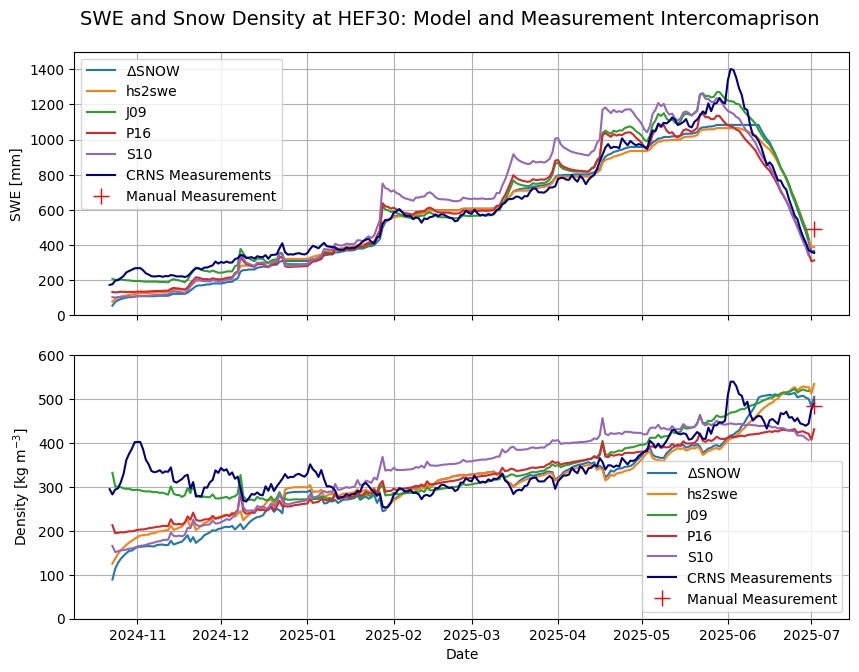

In [8]:
### plot model comparison


density_models = df_models.copy()
for col in density_models.columns[2:]:
    density_models[col] = df_models[col].values / daily_sd.values[1:]  # Adjust index alignment if needed

crns_density = daily_swe["median"].values / daily_sd.values

# --- Plotting ---
fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# --- 1. SWE Plot ---
for col in df_models.columns[2:]:
    axs[0].plot(df_models["date"], df_models[col], label=col)
axs[0].plot(daily_swe.index, daily_swe["median"], color="navy", label="CRNS Measurements")
axs[0].plot(pd.to_datetime('2025-07-02 00:00:00'), 489.17, marker='+', color='red', markersize=12, linestyle='', label='Manual Measurement')
axs[0].set_ylabel("SWE [mm]")
axs[0].set_ylim(0,1500)
axs[0].legend()
axs[0].grid(True)

# --- 2. Density Plot ---
for col in density_models.columns[2:]:
    axs[1].plot(df_models["date"], density_models[col], label=col)
axs[1].plot(daily_swe.index, crns_density, color="navy", label="CRNS Measurements")
axs[1].plot(pd.to_datetime('2025-07-02 00:00:00'), 484.33, marker='+', color='red', markersize=12, linestyle='', label='Manual Measurement')
axs[1].set_ylabel("Density [kg m$^{-3}$]")
axs[1].set_xlabel("Date")
axs[1].set_ylim(0,600)
axs[1].legend()
axs[1].grid(True)

# --- Title and Layout ---
fig.suptitle("SWE and Snow Density at HEF30: Model and Measurement Intercomaprison", fontsize=14)
fig.subplots_adjust(hspace=0.15, top=0.92)
#plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [9]:
### Calculate statistics for model-observation comparison


from scipy.stats import pearsonr

# Add observed series to df_models (ensure length matches!)
df_models["observed"] = daily_swe["median"][1:].values  # assumed length matches df_models

# Remove rows with any NaNs or infs
df_models = df_models.replace([np.inf, -np.inf], np.nan)
df_models = df_models.dropna()

# Dictionary to store results
results = {}

# Extract observed after cleaning
observed = df_models["observed"].values

# Loop through model columns (skipping 'date', 'snow height', and 'observed')
for col in df_models.columns[2:-1]:  # adjust if your cols are ['date', 'snow height', model1, model2, ..., 'observed']
    modeled = df_models[col].values

    # Calculate RMSE
    rmse = np.sqrt(np.mean((modeled - observed) ** 2))
    
    # Calculate Pearson correlation coefficient
    r, p_value = pearsonr(observed, modeled)

    # Store in dictionary
    results[col] = {
        "RMSE": round(rmse, 3),
        "Pearson r": round(r, 3),
        "p-value": round(p_value, 3)
    }

# Convert to DataFrame for display
results_df = pd.DataFrame(results)
print(results_df)


           $\Delta$SNOW  hs2swe     J09     P16      S10
RMSE             81.819  78.349  55.510  77.026  114.107
Pearson r         0.973   0.974   0.989   0.974    0.959
p-value           0.000   0.000   0.000   0.000    0.000
